In [1]:
import os
import re
import json
import zipfile
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from tqdm import tqdm

print("Libraries imported successfully.")
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Libraries imported successfully.
PyTorch version: 2.10.0+cpu
CUDA available: False


In [2]:
#reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

#device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

#main paths
ZIP_PATH = "caption_data.zip"
EXTRACT_DIR = "caption_data_extracted"

print("Current folder:", os.getcwd())

Using device: cpu
Current folder: C:\Users\gelas\Documents\visual-storyteller


In [3]:
if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError(
        "caption_data.zip was not found. Please upload/place caption_data.zip in the same folder as this notebook."
    )

print("Found dataset zip file:", ZIP_PATH)

if not os.path.exists(EXTRACT_DIR):
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
    print("Dataset extracted successfully.")
else:
    print("Dataset was already extracted.")

Found dataset zip file: caption_data.zip
Dataset was already extracted.


In [4]:
print("Dataset structure preview:\n")

for root, dirs, files in os.walk(EXTRACT_DIR):
    level = root.replace(EXTRACT_DIR, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")
    
    sub_indent = "    " * (level + 1)
    for file in files[:10]:
        print(f"{sub_indent}{file}")
    
    if level >= 2:
        break

Dataset structure preview:

caption_data_extracted/
    captions.txt
    Images/
        1000268201_693b08cb0e.jpg
        1001773457_577c3a7d70.jpg
        1002674143_1b742ab4b8.jpg
        1003163366_44323f5815.jpg
        1007129816_e794419615.jpg
        1007320043_627395c3d8.jpg
        1009434119_febe49276a.jpg
        1012212859_01547e3f17.jpg
        1015118661_980735411b.jpg
        1015584366_dfcec3c85a.jpg


In [5]:
#find image files
image_extensions = {".jpg", ".jpeg", ".png"}

all_image_paths = []
for root, dirs, files in os.walk(EXTRACT_DIR):
    for file in files:
        if Path(file).suffix.lower() in image_extensions:
            all_image_paths.append(os.path.join(root, file))

print("Number of image files found:", len(all_image_paths))

if len(all_image_paths) == 0:
    raise FileNotFoundError("No image files were found inside the extracted dataset.")

# Find possible caption text/csv files
possible_caption_files = []
for root, dirs, files in os.walk(EXTRACT_DIR):
    for file in files:
        lower_file = file.lower()
        if lower_file.endswith((".txt", ".csv")) and "caption" in lower_file:
            possible_caption_files.append(os.path.join(root, file))

print("Possible caption files:")
for path in possible_caption_files:
    print(path)

if len(possible_caption_files) == 0:
    raise FileNotFoundError("No caption file was found. Please send me the dataset structure output.")

Number of image files found: 8091
Possible caption files:
caption_data_extracted\captions.txt


In [6]:
caption_file = possible_caption_files[0]

print("Using caption file:", caption_file)
print("\nFirst 10 lines:\n")

with open(caption_file, "r", encoding="utf-8", errors="ignore") as f:
    for i in range(10):
        line = f.readline()
        print(line.strip())

Using caption file: caption_data_extracted\captions.txt

First 10 lines:

image,caption
1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set of stairs in an entry way .
1000268201_693b08cb0e.jpg,A girl going into a wooden building .
1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playhouse .
1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a wooden cabin .
1001773457_577c3a7d70.jpg,A black dog and a spotted dog are fighting
1001773457_577c3a7d70.jpg,A black dog and a tri-colored dog playing with each other on the road .
1001773457_577c3a7d70.jpg,A black dog and a white dog with brown spots are staring at each other in the street .
1001773457_577c3a7d70.jpg,Two dogs of different breeds looking at each other on the road .


In [7]:
def load_captions(caption_file):
    """
    Loads captions from common image-captioning dataset formats.
    Supports formats like:
    image,caption
    image.jpg,A dog is running.
    image.jpg#0 A dog is running.
    image.jpg\tA dog is running.
    """
    
    rows = []
    
    with open(caption_file, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()
    
    #semove empty lines
    lines = [line.strip() for line in lines if line.strip()]
    
    #skip header if it looks like one
    if lines[0].lower().replace(" ", "") in ["image,caption", "image_name,caption", "filename,caption"]:
        lines = lines[1:]
    
    for line in lines:
        image_name = None
        caption = None
        
        #format: image.jpg#0 caption
        if "#" in line and ("jpg" in line.lower() or "png" in line.lower()):
            parts = line.split(maxsplit=1)
            if len(parts) == 2:
                image_part = parts[0]
                image_name = image_part.split("#")[0]
                caption = parts[1]
        
        #Format: image.jpg<TAB>caption
        elif "\t" in line:
            parts = line.split("\t")
            if len(parts) >= 2:
                image_name = parts[0].strip()
                caption = " ".join(parts[1:]).strip()
        
        # Format: image.jpg,caption
        elif "," in line:
            parts = line.split(",", 1)
            if len(parts) == 2:
                image_name = parts[0].strip()
                caption = parts[1].strip()
        
        if image_name is not None and caption is not None:
            rows.append({
                "image": image_name,
                "caption": caption
            })
    
    return pd.DataFrame(rows)

captions_df = load_captions(caption_file)

print("Captions loaded:", len(captions_df))
print("Unique images in captions:", captions_df["image"].nunique())
captions_df.head(10)

Captions loaded: 40455
Unique images in captions: 8103


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...
5,1001773457_577c3a7d70.jpg,A black dog and a spotted dog are fighting
6,1001773457_577c3a7d70.jpg,A black dog and a tri-colored dog playing with...
7,1001773457_577c3a7d70.jpg,A black dog and a white dog with brown spots a...
8,1001773457_577c3a7d70.jpg,Two dogs of different breeds looking at each o...
9,1001773457_577c3a7d70.jpg,Two dogs on pavement moving toward each other .


In [8]:
# create dictionary: image filename -> full path
image_path_dict = {}

for path in all_image_paths:
    filename = os.path.basename(path)
    image_path_dict[filename] = path

print("Image path dictionary size:", len(image_path_dict))

#add full image paths to dataframe
captions_df["image_path"] = captions_df["image"].map(image_path_dict)

# Remove rows where image path was not found
missing_paths = captions_df["image_path"].isna().sum()
print("Missing image paths:", missing_paths)

captions_df = captions_df.dropna(subset=["image_path"]).reset_index(drop=True)

print("Final captions dataframe size:", len(captions_df))
print("Final unique images:", captions_df["image"].nunique())

captions_df.head()

Image path dictionary size: 8091
Missing image paths: 12
Final captions dataframe size: 40443
Final unique images: 8091


,image,caption,image_path
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...,caption_data_extracted\Images\1000268201_693b0...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .,caption_data_extracted\Images\1000268201_693b0...
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .,caption_data_extracted\Images\1000268201_693b0...
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...,caption_data_extracted\Images\1000268201_693b0...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...,caption_data_extracted\Images\1000268201_693b0...


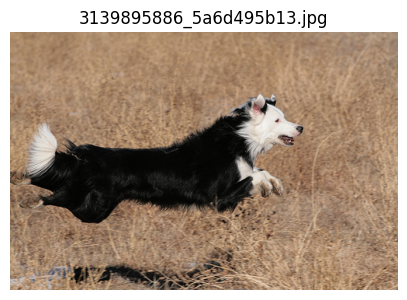

Captions:
- "A black-and-white dog bounds off the ground , all feet in the air , of a yellow field ."
- A black and white dog is jumping over high yellow grass .
- A black and white dog is jumping through a field of brown grass .
- a dog runs through the dry grass .
- The black and white dog runs through the field .

--------------------------------------------------------------------------------



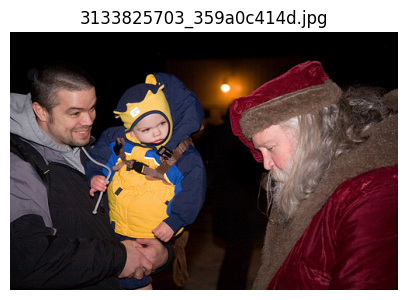

Captions:
- A child staring at Santa .
- A father and son looking at a funny looking Santa .
- A little boy and his father talking to a man dressed as Santa Claws .
- The child is looking at Santa Claus .
- The little boy has a yellow crown and the man is wearing red velvet .

--------------------------------------------------------------------------------



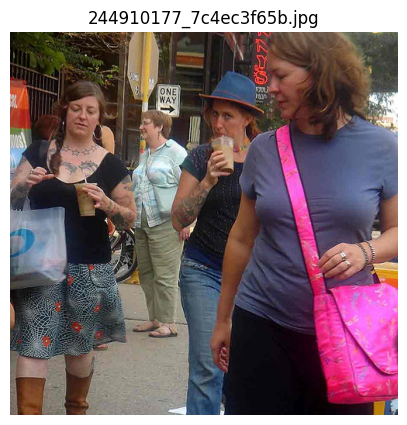

Captions:
- Three woman walk down a city street and one has a pink purse .
- "Three women , two with tattoos , walking down the street"
- Women are walking through the street drinking iced coffee .
- Women walk down a buzy sidewalk .
- Women walking down the street .

--------------------------------------------------------------------------------



In [9]:
sample_images = captions_df["image"].drop_duplicates().sample(3, random_state=SEED).tolist()

for img_name in sample_images:
    img_path = image_path_dict[img_name]
    img = Image.open(img_path).convert("RGB")
    
    related_captions = captions_df[captions_df["image"] == img_name]["caption"].tolist()
    
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_name)
    plt.show()
    
    print("Captions:")
    for cap in related_captions:
        print("-", cap)
    print("\n" + "-" * 80 + "\n")

##caption Preprocessing

Before training the model the captions need to be cleaned and converted into a format that the neural network can use.

For each caption I will:
- convert text to lowercase
- remove unnecessary characters
- add a start token
- add an end token

The start and end tokens help the model understand where the generated sentence begins and ends.

In [11]:
def clean_caption(caption):
    """
    Cleans a caption and adds start/end tokens.
    """
    caption = caption.lower()
    caption = re.sub(r"[^a-zA-Z0-9\s]", "", caption)
    caption = re.sub(r"\s+", " ", caption).strip()
    caption = "<start> " + caption + " <end>"
    return caption

captions_df["clean_caption"] = captions_df["caption"].apply(clean_caption)

print("Original caption:")
print(captions_df["caption"].iloc[0])

print("\nCleaned caption:")
print(captions_df["clean_caption"].iloc[0])

captions_df.head()

Original caption:
A child in a pink dress is climbing up a set of stairs in an entry way .

Cleaned caption:
<start> a child in a pink dress is climbing up a set of stairs in an entry way <end>


,image,caption,image_path,clean_caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...,caption_data_extracted\Images\1000268201_693b0...,<start> a child in a pink dress is climbing up...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .,caption_data_extracted\Images\1000268201_693b0...,<start> a girl going into a wooden building <end>
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .,caption_data_extracted\Images\1000268201_693b0...,<start> a little girl climbing into a wooden p...
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...,caption_data_extracted\Images\1000268201_693b0...,<start> a little girl climbing the stairs to h...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...,caption_data_extracted\Images\1000268201_693b0...,<start> a little girl in a pink dress going in...


Caption length statistics:
count    40443.000000
mean        12.789828
std          3.757364
min          3.000000
25%         10.000000
50%         12.000000
75%         15.000000
max         38.000000
Name: caption_length, dtype: float64


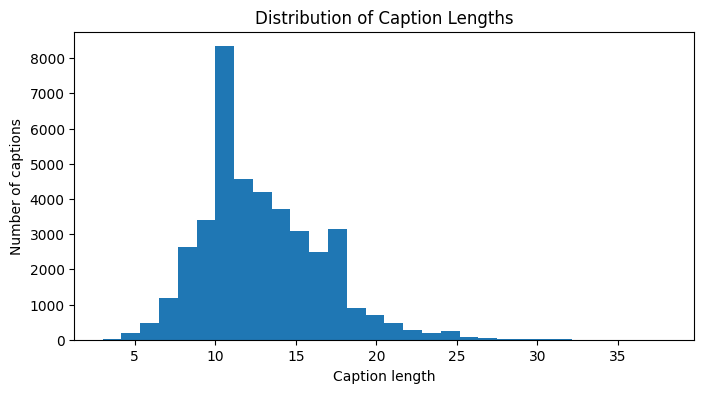

In [12]:
captions_df["caption_length"] = captions_df["clean_caption"].apply(lambda x: len(x.split()))

print("Caption length statistics:")
print(captions_df["caption_length"].describe())

plt.figure(figsize=(8, 4))
plt.hist(captions_df["caption_length"], bins=30)
plt.xlabel("Caption length")
plt.ylabel("Number of captions")
plt.title("Distribution of Caption Lengths")
plt.show()

In [13]:
MAX_CAPTION_LENGTH = int(captions_df["caption_length"].quantile(0.95))

print("Maximum caption length used:", MAX_CAPTION_LENGTH)

Maximum caption length used: 20


Vocabulary Creation

Neural networks cannot directly understand words, so each word must be converted into a number.

I create a vocabulary from the training captions.  
Special tokens are also added:

- `<pad>` is used for padding shorter captions
- `<start>` marks the beginning of a caption
- `<end>` marks the end of a caption
- `<unk>` is used for unknown words

In [14]:
unique_images = captions_df["image"].unique()

train_images, val_images = train_test_split(
    unique_images,
    test_size=0.2,
    random_state=SEED
)

train_df = captions_df[captions_df["image"].isin(train_images)].reset_index(drop=True)
val_df = captions_df[captions_df["image"].isin(val_images)].reset_index(drop=True)

print("Training images:", len(train_images))
print("Validation images:", len(val_images))
print("Training captions:", len(train_df))
print("Validation captions:", len(val_df))

Training images: 6472
Validation images: 1619
Training captions: 32351
Validation captions: 8092


In [15]:
MIN_WORD_FREQ = 3

word_counter = Counter()

for caption in train_df["clean_caption"]:
    words = caption.split()
    word_counter.update(words)

special_tokens = ["<pad>", "<start>", "<end>", "<unk>"]

vocab_words = special_tokens.copy()

for word, count in word_counter.items():
    if count >= MIN_WORD_FREQ and word not in special_tokens:
        vocab_words.append(word)

word_to_idx = {word: idx for idx, word in enumerate(vocab_words)}
idx_to_word = {idx: word for word, idx in word_to_idx.items()}

PAD_IDX = word_to_idx["<pad>"]
START_IDX = word_to_idx["<start>"]
END_IDX = word_to_idx["<end>"]
UNK_IDX = word_to_idx["<unk>"]

VOCAB_SIZE = len(word_to_idx)

print("Vocabulary size:", VOCAB_SIZE)
print("PAD index:", PAD_IDX)
print("START index:", START_IDX)
print("END index:", END_IDX)
print("UNK index:", UNK_IDX)

Vocabulary size: 3673
PAD index: 0
START index: 1
END index: 2
UNK index: 3


In [21]:
def encode_caption(caption, word_to_idx, max_length):
    """
    Converts a cleaned caption into a list of word indices.
    """
    words = caption.split()
    
    encoded = []
    for word in words:
        encoded.append(word_to_idx.get(word, UNK_IDX))
    
    # Cut captions that are too long, but keep <end> at the end
    if len(encoded) > max_length:
        encoded = encoded[:max_length]
        encoded[-1] = END_IDX
    
    # Pad captions that are too short
    if len(encoded) < max_length:
        encoded += [PAD_IDX] * (max_length - len(encoded))
    
    return encoded

example_caption = train_df["clean_caption"].iloc[0]
example_encoded = encode_caption(example_caption, word_to_idx, MAX_CAPTION_LENGTH)

print("Example caption:")
print(example_caption)

print("\nEncoded caption:")
print(example_encoded)

print("\nDecoded back:")
print(" ".join([idx_to_word[idx] for idx in example_encoded if idx != PAD_IDX]))

Example caption:
<start> a child in a pink dress is climbing up a set of stairs in an entry way <end>

Encoded caption:
[1, 4, 5, 6, 4, 7, 8, 9, 10, 11, 4, 12, 13, 14, 6, 15, 3, 16, 2, 0]

Decoded back:
<start> a child in a pink dress is climbing up a set of stairs in an <unk> way <end>


Image Transformations

The images are resized and normalized before being passed into the neural network.

This makes all images have the same size and format.

In [17]:
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Image transformation is ready.")

Image transformation is ready.


In [18]:
class CaptionDataset(Dataset):
    def __init__(self, dataframe, word_to_idx, max_length, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.word_to_idx = word_to_idx
        self.max_length = max_length
        self.transform = transform
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        
        image_path = row["image_path"]
        caption = row["clean_caption"]
        
        image = Image.open(image_path).convert("RGB")
        
        if self.transform is not None:
            image = self.transform(image)
        
        caption_encoded = encode_caption(
            caption,
            self.word_to_idx,
            self.max_length
        )
        
        caption_tensor = torch.tensor(caption_encoded, dtype=torch.long)
        
        return image, caption_tensor

In [19]:
BATCH_SIZE = 32

train_dataset = CaptionDataset(
    dataframe=train_df,
    word_to_idx=word_to_idx,
    max_length=MAX_CAPTION_LENGTH,
    transform=image_transform
)

val_dataset = CaptionDataset(
    dataframe=val_df,
    word_to_idx=word_to_idx,
    max_length=MAX_CAPTION_LENGTH,
    transform=image_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Training batches: 1011
Validation batches: 253


In [20]:
images, captions = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Caption batch shape:", captions.shape)

print("\nExample encoded caption from batch:")
print(captions[0])

print("\nDecoded caption:")
decoded_words = []
for idx in captions[0].tolist():
    if idx == PAD_IDX:
        break
    decoded_words.append(idx_to_word.get(idx, "<unk>"))

print(" ".join(decoded_words))

Image batch shape: torch.Size([32, 3, 224, 224])
Caption batch shape: torch.Size([32, 20])

Example encoded caption from batch:
tensor([  1,   4,   5,   6,  24, 170,   2,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0])

Decoded caption:
<start> a child in the snow <end>


Model Definition

For this project, I use an encoder-decoder architecture.
The encoder is a CNN that extracts visual features from the image.  
The decoder is an LSTM network that generates the caption word by word.

The image is first converted into a feature vector by the encoder.  
Then the decoder uses this feature vector together with the previous caption words to predict the next word.

In [23]:
class CNNEncoder(nn.Module):
    def __init__(self, embed_size):
        super(CNNEncoder, self).__init__()
        
        # I use ResNet18 as the visual feature extractor
        # If pretrained weights are available they are used
        # If not the model still works with random weights
        try:
            weights = models.ResNet18_Weights.DEFAULT
            resnet = models.resnet18(weights=weights)
            print("Using pretrained ResNet18 weights.")
        except Exception as e:
            resnet = models.resnet18(weights=None)
            print("Could not load pretrained weights. Using ResNet18 without pretrained weights.")
            print("Reason:", e)
        
        # remove the final classification layer
        modules = list(resnet.children())[:-1]
        self.resnet = nn.Sequential(*modules)
        
        # freeze cnn parameters to make training faster
        for param in self.resnet.parameters():
            param.requires_grad = False
        
        # Resnet18 outputs 512 features
        self.fc = nn.Linear(512, embed_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
    
    def forward(self, images):
        with torch.no_grad():
            features = self.resnet(images)
        
        features = features.view(features.size(0), -1)
        features = self.fc(features)
        features = self.relu(features)
        features = self.dropout(features)
        
        return features

In [24]:
class LSTMDecoder(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers=1):
        super(LSTMDecoder, self).__init__()
        
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(
            input_size=embed_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        
        self.init_h = nn.Linear(embed_size, hidden_size)
        self.init_c = nn.Linear(embed_size, hidden_size)
        self.fc = nn.Linear(hidden_size, vocab_size)
    
    def forward(self, image_features, captions):
        """
        image_features: output from encoder
        captions: input captions without the last word
        """
        
        embeddings = self.embed(captions)
        
        h0 = torch.tanh(self.init_h(image_features)).unsqueeze(0)
        c0 = torch.tanh(self.init_c(image_features)).unsqueeze(0)
        
        lstm_outputs, _ = self.lstm(embeddings, (h0, c0))
        outputs = self.fc(lstm_outputs)
        
        return outputs

In [25]:
class ImageCaptioningModel(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers=1):
        super(ImageCaptioningModel, self).__init__()
        
        self.encoder = CNNEncoder(embed_size)
        self.decoder = LSTMDecoder(
            embed_size=embed_size,
            hidden_size=hidden_size,
            vocab_size=vocab_size,
            num_layers=num_layers
        )
    
    def forward(self, images, captions):
        """
        During training:
        captions_input contains all words except the last word
        targets contain all words except the first word
        
        Example:
        input:  <start> a dog is running
        target: a dog is running <end>
        """
        
        image_features = self.encoder(images)
        outputs = self.decoder(image_features, captions)
        
        return outputs

In [26]:
EMBED_SIZE = 256
HIDDEN_SIZE = 512
NUM_LAYERS = 1

model = ImageCaptioningModel(
    embed_size=EMBED_SIZE,
    hidden_size=HIDDEN_SIZE,
    vocab_size=VOCAB_SIZE,
    num_layers=NUM_LAYERS
).to(device)

print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\gelas/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|█████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [00:06<00:00, 7.56MB/s]


Using pretrained ResNet18 weights.
ImageCaptioningModel(
  (encoder): CNNEncoder(
    (resnet): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (4): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias

In [27]:
# test one batch before training
images, captions = next(iter(train_loader))

images = images.to(device)
captions = captions.to(device)

# input captions do not include the last token
caption_inputs = captions[:, :-1]

# target captions do not include the first token
caption_targets = captions[:, 1:]

outputs = model(images, caption_inputs)

print("Caption input shape:", caption_inputs.shape)
print("Caption target shape:", caption_targets.shape)
print("Model output shape:", outputs.shape)
print("Expected output shape: [batch_size, sequence_length, vocab_size]")

Caption input shape: torch.Size([32, 19])
Caption target shape: torch.Size([32, 19])
Model output shape: torch.Size([32, 19, 3673])
Expected output shape: [batch_size, sequence_length, vocab_size]


In [28]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001
)

print("Loss function and optimizer are ready.")

Loss function and optimizer are ready.
